# Projet 5A - Prédiction de matchs

### Comparaison des sous-datasets

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration d'affichage 
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Dossier de données 
DATA_DIR = "C:/Users/Alban/Documents/IMDS/Projet_5A/Donnees"

In [45]:
# Datasets disponibles
datasets = {
    "Matches_with_Elo": "Matches_with_Elo.csv",
    "Pred_Full": "matches_pred_full.csv",
    "Recent": "matches_recent.csv",
    "Clean": "matches_clean.csv",
    "Select_Championnats": "matches_select_championnats.csv"
}

# Fonction de chargement
def load_dataset(name, file):
    path = os.path.join(DATA_DIR, file)
    df = pd.read_csv(path, sep=";", low_memory=False)
    df["MatchDate"] = pd.to_datetime(df["MatchDate"], errors="coerce")
    df["Season"] = df["MatchDate"].dt.year
    return df

dfs = {name: load_dataset(name, file) for name, file in datasets.items()}

print(f"{len(dfs)} datasets chargés avec succès :")
for k, v in dfs.items():
    print(f"  - {k}: {len(v):,} lignes, {v.shape[1]} colonnes")

C:\Users\Alban\AppData\Local\Temp\ipykernel_24244\175826054.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["MatchDate"] = pd.to_datetime(df["MatchDate"], errors="coerce")
C:\Users\Alban\AppData\Local\Temp\ipykernel_24244\175826054.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["MatchDate"] = pd.to_datetime(df["MatchDate"], errors="coerce")


5 datasets chargés avec succès :
  - Matches_with_Elo: 165,619 lignes, 67 colonnes
  - Pred_Full: 165,619 lignes, 48 colonnes
  - Recent: 138,312 lignes, 46 colonnes
  - Clean: 8,478 lignes, 35 colonnes
  - Select_Championnats: 52,580 lignes, 48 colonnes


C:\Users\Alban\AppData\Local\Temp\ipykernel_24244\175826054.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["MatchDate"] = pd.to_datetime(df["MatchDate"], errors="coerce")


In [46]:
summary = []

for name, df in dfs.items():
    compl = (1 - df.isna().mean().mean()) * 100
    summary.append({
        "Dataset": name,
        "Lignes": len(df),
        "Colonnes": df.shape[1],
        "Année min": df["Season"].min(),
        "Année max": df["Season"].max(),
        "Nb Divisions": df["Division"].nunique() if "Division" in df.columns else np.nan,
        "Nb Clubs": pd.unique(pd.concat([df["HomeTeam"], df["AwayTeam"]])).size if "HomeTeam" in df.columns else np.nan,
        "Complétude (%)": round(compl, 2)
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

print("\nVue d’ensemble : tailles, années, divisions et complétude moyenne.")

,Dataset,Lignes,Colonnes,Année min,Année max,Nb Divisions,Nb Clubs,Complétude (%)
0,Matches_with_Elo,165619,67,2000.0,2025.0,30,933,82.02
1,Pred_Full,165619,48,2000.0,2025.0,30,933,92.24
2,Recent,138312,46,2006.0,2025.0,30,896,92.00
3,Clean,8478,35,2024.0,2025.0,29,545,94.91
4,Select_Championnats,52580,48,2006.0,2025.0,11,350,97.35



Vue d’ensemble : tailles, années, divisions et complétude moyenne.


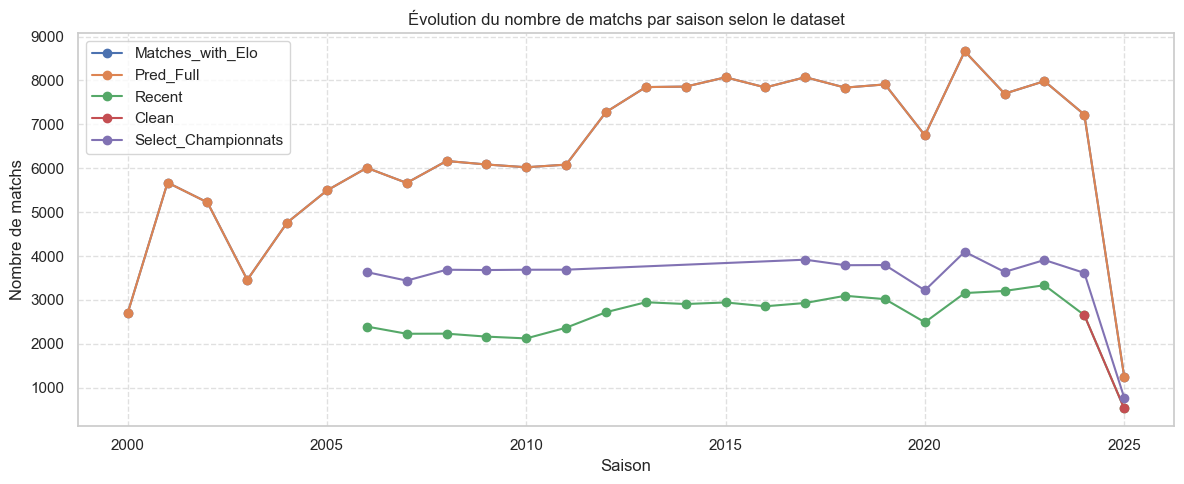

In [47]:
plt.figure(figsize=(12,5))

for name, df in dfs.items():
    matches_per_year = df.groupby("Season").size()
    plt.plot(matches_per_year.index, matches_per_year.values, marker="o", label=name)

plt.title("Évolution du nombre de matchs par saison selon le dataset")
plt.xlabel("Saison")
plt.ylabel("Nombre de matchs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\Alban\AppData\Local\Temp\ipykernel_24244\466633924.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compl_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())
C:\Users\Alban\AppData\Local\Temp\ipykernel_24244\466633924.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compl_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())
C:\Users\Alban\AppData\Local\T

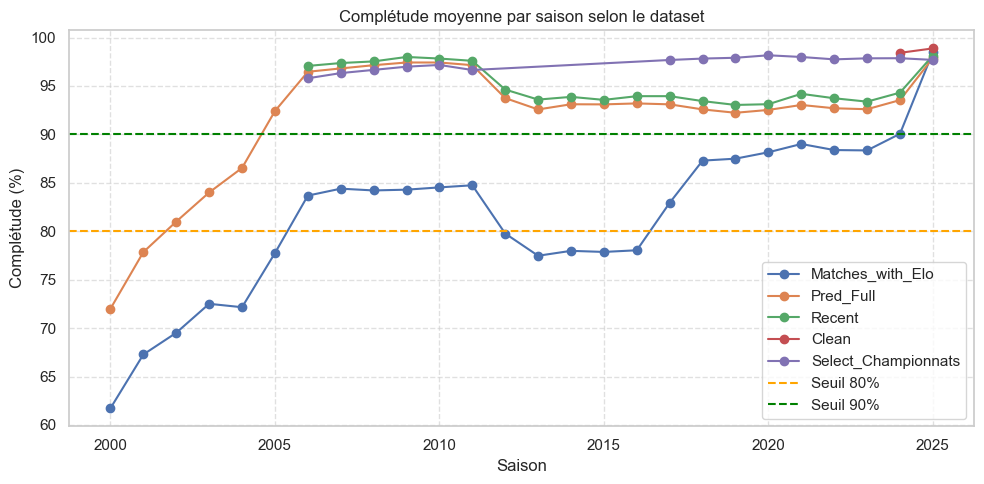

In [48]:
plt.figure(figsize=(10,5))

for name, df in dfs.items():
    compl_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())
    plt.plot(compl_by_season.index, compl_by_season.values*100, marker="o", label=name)

plt.axhline(80, color="orange", linestyle="--", label="Seuil 80%")
plt.axhline(90, color="green", linestyle="--", label="Seuil 90%")
plt.title("Complétude moyenne par saison selon le dataset")
plt.xlabel("Saison")
plt.ylabel("Complétude (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Analyse univariée comparative

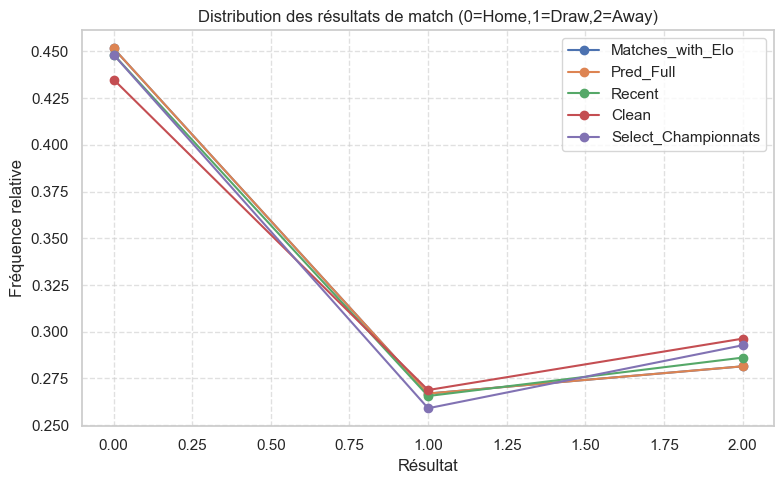

In [49]:
plt.figure(figsize=(8,5))

for name, df in dfs.items():
    if "FTResult" not in df.columns:
        continue
    df["FTResult_num"] = df["FTResult"].map({"H":0,"D":1,"A":2})
    dist = df["FTResult_num"].value_counts(normalize=True).sort_index()
    plt.plot(dist.index, dist.values, marker="o", label=name)

plt.title("Distribution des résultats de match (0=Home,1=Draw,2=Away)")
plt.xlabel("Résultat")
plt.ylabel("Fréquence relative")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [50]:
df_compare = pd.concat(
    [df.assign(source=name) for name, df in dfs.items()],
    ignore_index=True
)

print("Datasets disponibles :", list(dfs.keys()))
df_compare.head()

Datasets disponibles : ['Matches_with_Elo', 'Pred_Full', 'Recent', 'Clean', 'Select_Championnats']


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,Form3Home,Form5Home,Form3Away,Form5Away,FTHome,FTAway,FTResult,HTHome,HTAway,HTResult,HomeShots,AwayShots,HomeTarget,AwayTarget,HomeFouls,AwayFouls,HomeCorners,AwayCorners,HomeYellow,HomeRed,AwayRed,OddHome,OddDraw,OddAway,Over25,Under25,MaxOver25,MaxUnder25,HandiSize,HandiHome,HandiAway,HomeEloSnap,HomeEloChange1M,HomeEloChange3M,HomeEloChange6M,AwayEloSnap,AwayEloChange1M,AwayEloChange3M,AwayEloChange6M,EloChange1M_Diff,EloChange3M_Diff,EloChange6M_Diff,EloDiff,EloTotal,EloAdvantage,Form3Diff,Form5Diff,FormMomentumHome,FormMomentumAway,ProbSum,PHome_norm,PDraw_norm,PAway_norm,ShotsDifference,CornersDifference,CardsHome,CardsAway,CardsDiff,GameDominanceIndex,Country,country.1,Season,FTResult_num,source,Division_1,MatchDate_2,HomeTeam_3,AwayTeam_4
0,T1,2003-08-17,NaN,Malatyaspor,A. Sebatspor,9.0,12.0,0.0,0.0,3.0,1.0,H,1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.44,3.75,6.0,NaN,NaN,NaN,NaN,-1.3,1.95,1.85,1475.74,12.98,36.66,41.33,1366.00,-6.68,NaN,NaN,19.66,NaN,NaN,109.74,2841.74,0.038617,9.0,12.0,6.0,0.0,1.127778,0.615764,0.236453,0.147783,NaN,NaN,NaN,NaN,NaN,NaN,TUR,TUR,2003.0,0.0,Matches_with_Elo,NaN,NaN,NaN,NaN
1,T1,2003-08-31,NaN,Trabzonspor,A. Sebatspor,4.0,7.0,0.0,0.0,2.0,1.0,H,1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.33,4.33,7.0,NaN,NaN,NaN,NaN,-1.5,1.88,1.90,1465.57,4.98,-1.88,-9.92,1366.00,-6.68,NaN,NaN,11.66,NaN,NaN,99.57,2831.57,0.035164,4.0,7.0,1.0,0.0,1.125684,0.667932,0.205161,0.126907,NaN,NaN,NaN,NaN,NaN,NaN,TUR,TUR,2003.0,0.0,Matches_with_Elo,NaN,NaN,NaN,NaN
2,T1,2003-09-21,NaN,Diyarbakirspor,A. Sebatspor,0.0,3.0,3.0,3.0,1.0,0.0,H,1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.72,3.40,4.0,NaN,NaN,NaN,NaN,-0.8,1.95,1.75,1377.36,-8.86,-5.37,-31.56,1349.40,-16.60,NaN,NaN,7.74,NaN,NaN,27.96,2726.76,0.010254,-3.0,0.0,-3.0,3.0,1.125513,0.516560,0.261319,0.222121,NaN,NaN,NaN,NaN,NaN,NaN,TUR,TUR,2003.0,0.0,Matches_with_Elo,NaN,NaN,NaN,NaN
3,T1,2003-10-04,NaN,Galatasaray,A. Sebatspor,4.0,8.0,3.0,3.0,4.0,3.0,H,1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.14,6.00,12.0,NaN,NaN,NaN,NaN,-2.3,1.80,1.90,1686.97,-25.80,0.11,1.82,1343.98,-5.42,-28.70,NaN,-20.38,28.81,NaN,342.99,3030.95,0.113163,1.0,5.0,0.0,3.0,1.127193,0.778210,0.147860,0.073930,NaN,NaN,NaN,NaN,NaN,NaN,TUR,TUR,2003.0,0.0,Matches_with_Elo,NaN,NaN,NaN,NaN
4,T1,2003-10-26,NaN,Konyaspor,A. Sebatspor,1.0,4.0,0.0,3.0,0.0,0.0,D,0.0,0.0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.57,3.50,5.0,NaN,NaN,NaN,NaN,-1.0,2.05,1.70,1387.23,-13.26,14.55,NaN,1352.10,2.70,-20.58,NaN,-15.96,35.13,NaN,35.13,2739.33,0.012824,1.0,1.0,-2.0,-3.0,1.122657,0.567353,0.254498,0.178149,NaN,NaN,NaN,NaN,NaN,NaN,TUR,TUR,2003.0,1.0,Matches_with_Elo,NaN,NaN,NaN,NaN


### FTResult : comparaison des proportions par dataset

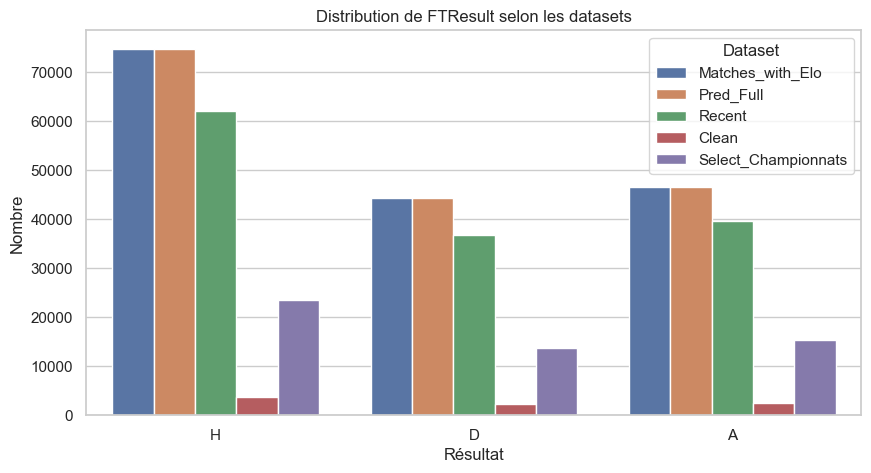

Proportions de résultats par dataset :

FTResult                    A         D         H
source                                           
Clean                0.296296  0.268813  0.434890
Matches_with_Elo     0.281499  0.266941  0.451560
Pred_Full            0.281499  0.266941  0.451560
Recent               0.286147  0.265621  0.448232
Select_Championnats  0.292754  0.259072  0.448174


In [51]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_compare, x="FTResult", hue="source", order=["H","D","A"])
plt.title("Distribution de FTResult selon les datasets")
plt.xlabel("Résultat")
plt.ylabel("Nombre")
plt.legend(title="Dataset")
plt.show()

ft_tab = pd.crosstab(df_compare["source"], df_compare["FTResult"], normalize="index")
print("Proportions de résultats par dataset :\n")
print(ft_tab)

### Elo : distributions comparatives HOME / AWAY

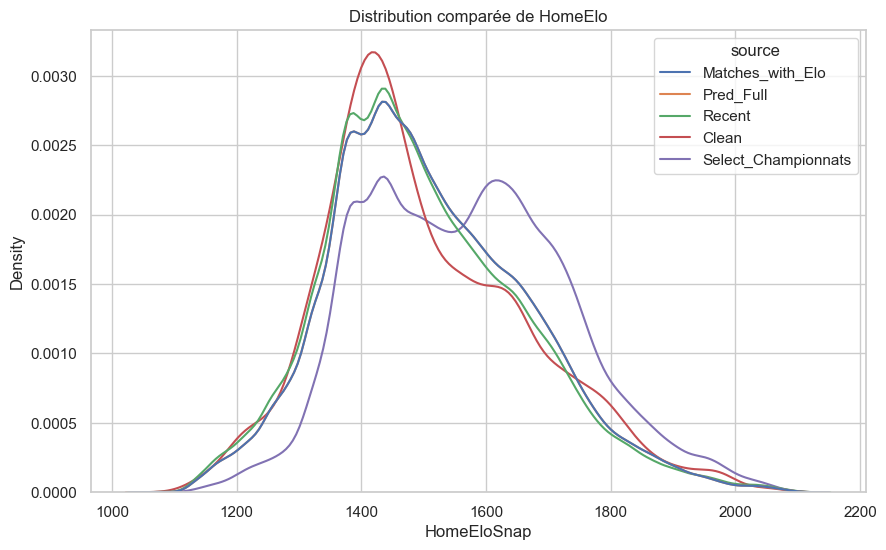

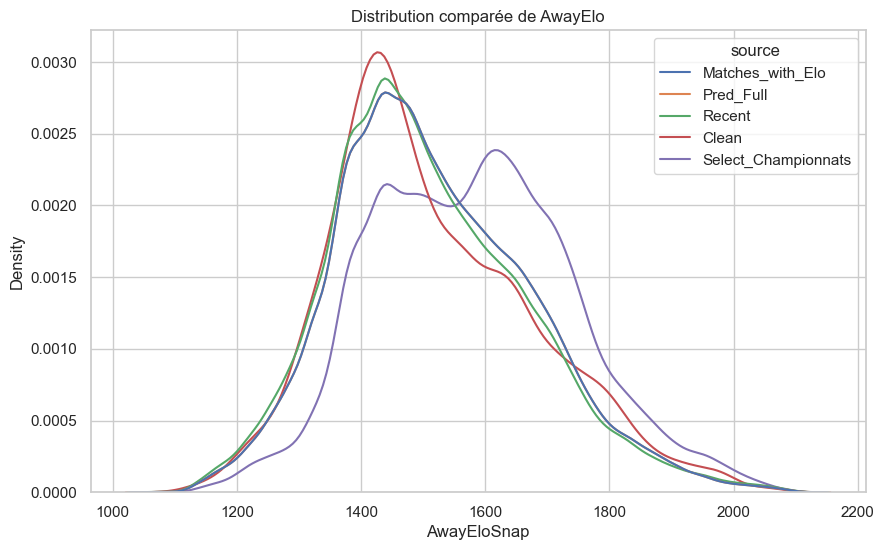

In [52]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_compare, x="HomeEloSnap", hue="source", common_norm=False)
plt.title("Distribution comparée de HomeElo")
plt.show()

plt.figure(figsize=(10,6))
sns.kdeplot(data=df_compare, x="AwayEloSnap", hue="source", common_norm=False)
plt.title("Distribution comparée de AwayElo")
plt.show()

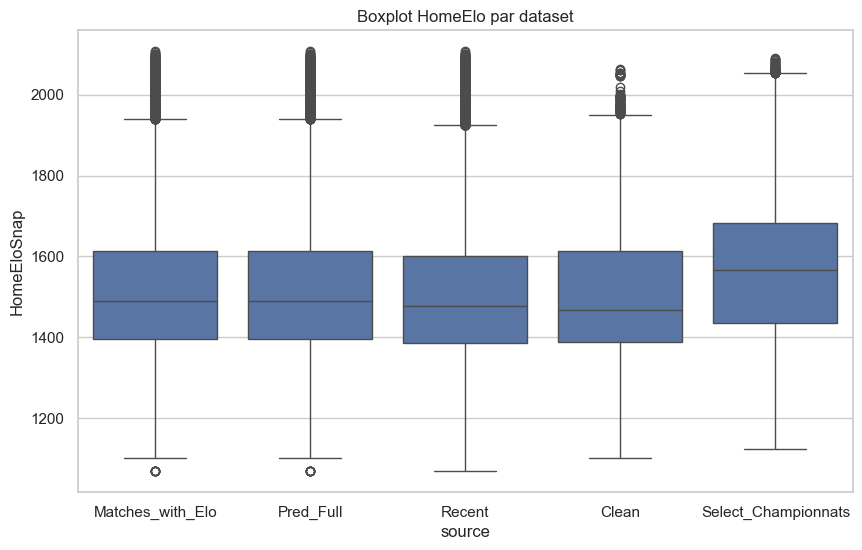

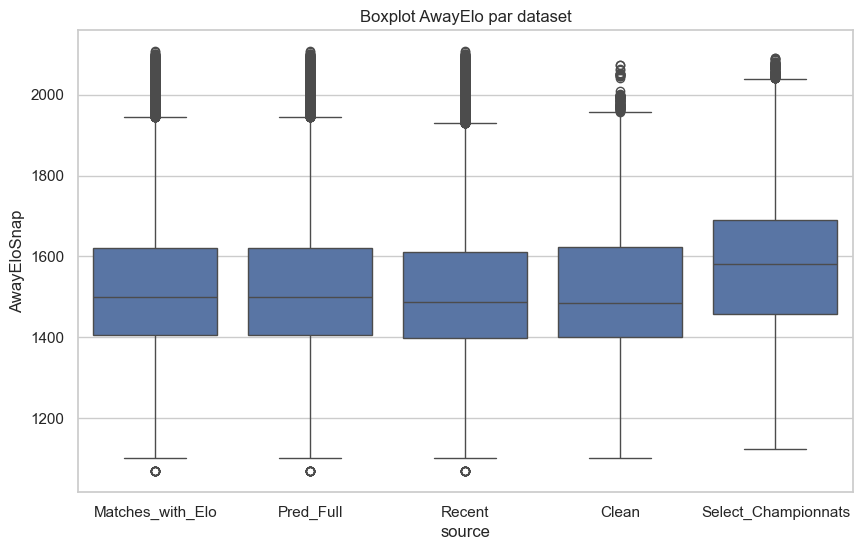

In [53]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_compare, x="source", y="HomeEloSnap")
plt.title("Boxplot HomeElo par dataset")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df_compare, x="source", y="AwayEloSnap")
plt.title("Boxplot AwayElo par dataset")
plt.show()

### Formes (Form3 / Form5)

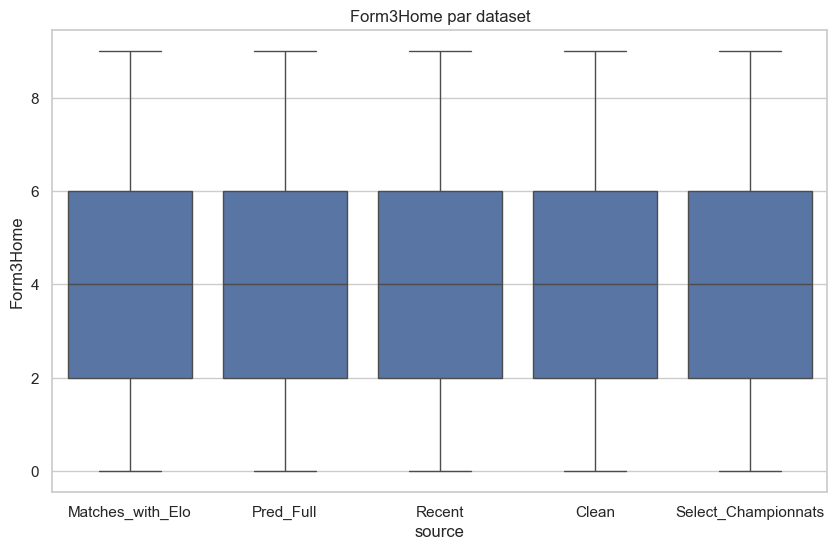

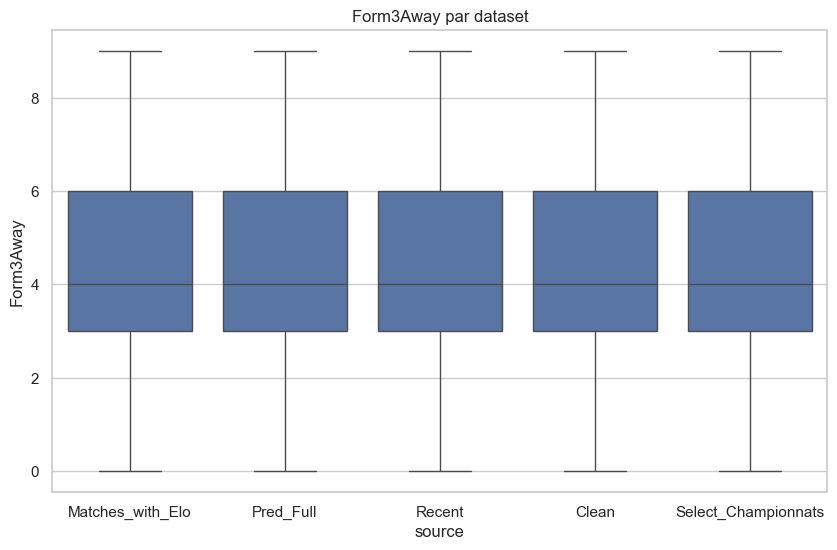

In [54]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_compare, x="source", y="Form3Home")
plt.title("Form3Home par dataset")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df_compare, x="source", y="Form3Away")
plt.title("Form3Away par dataset")
plt.show()

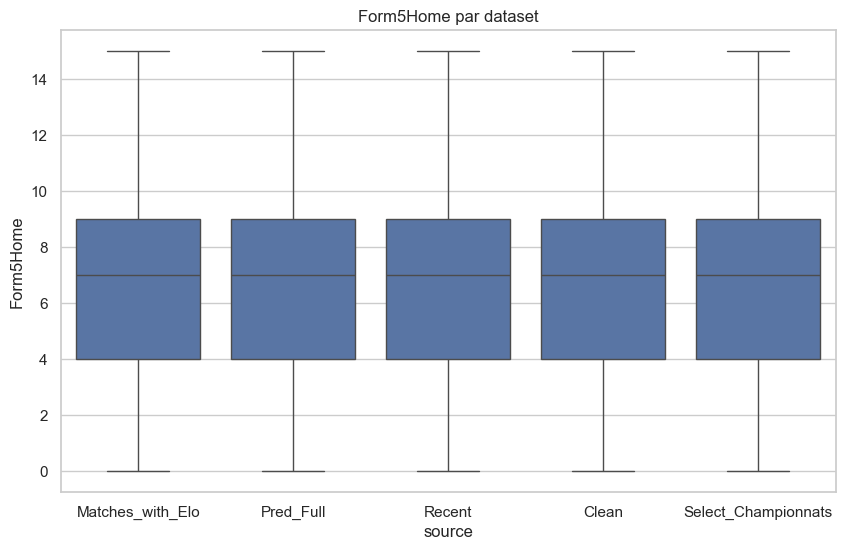

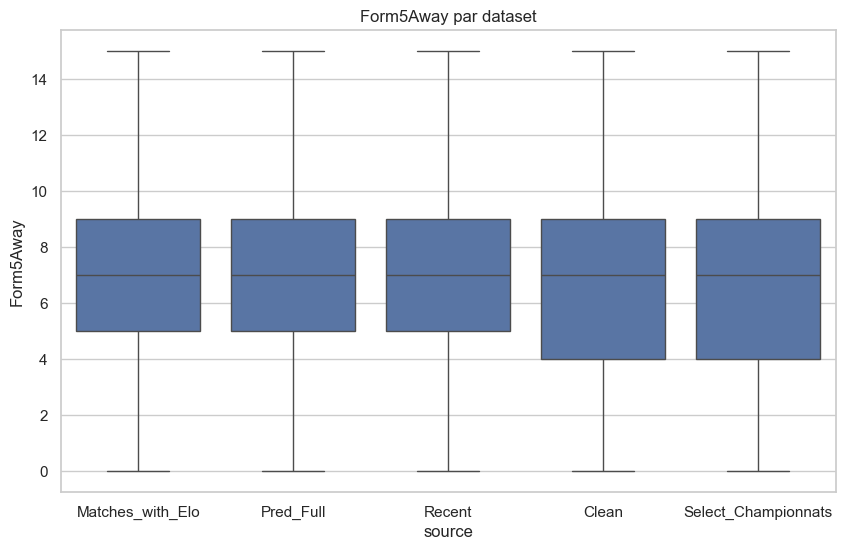

In [55]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_compare, x="source", y="Form5Home")
plt.title("Form5Home par dataset")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df_compare, x="source", y="Form5Away")
plt.title("Form5Away par dataset")
plt.show()

### Odds : comparaison des distributions

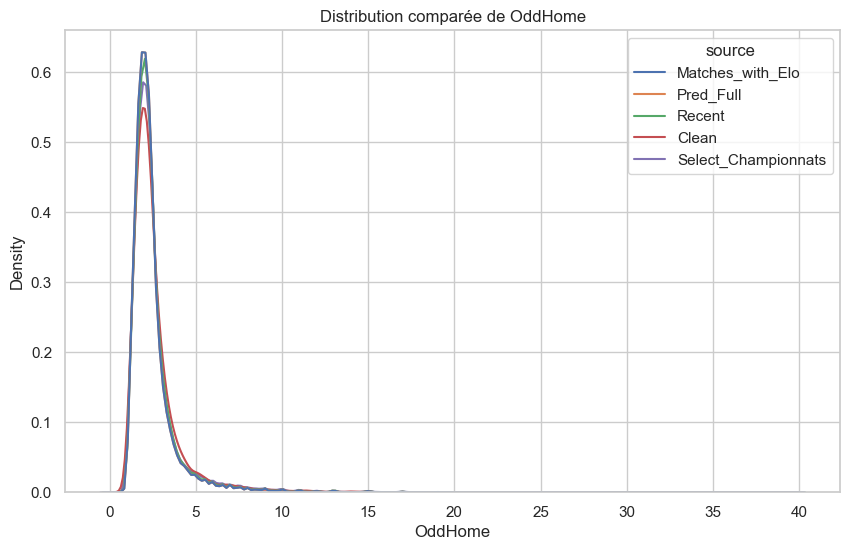

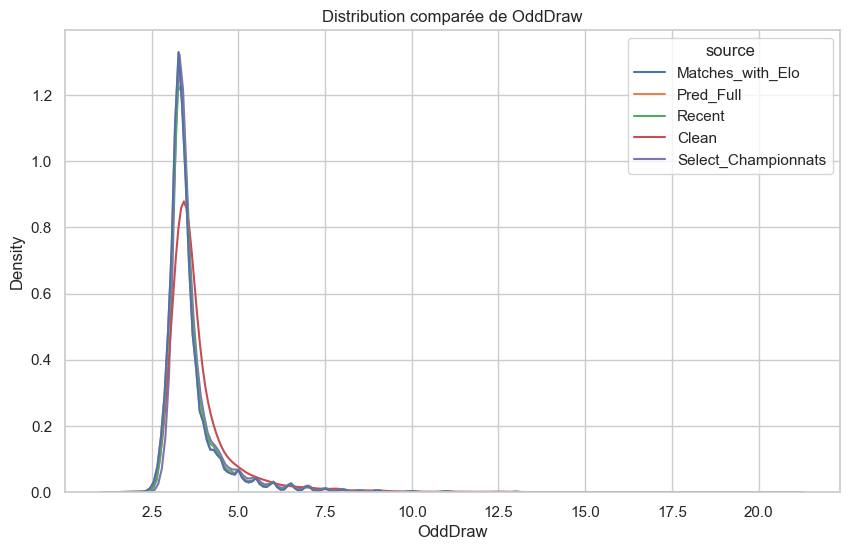

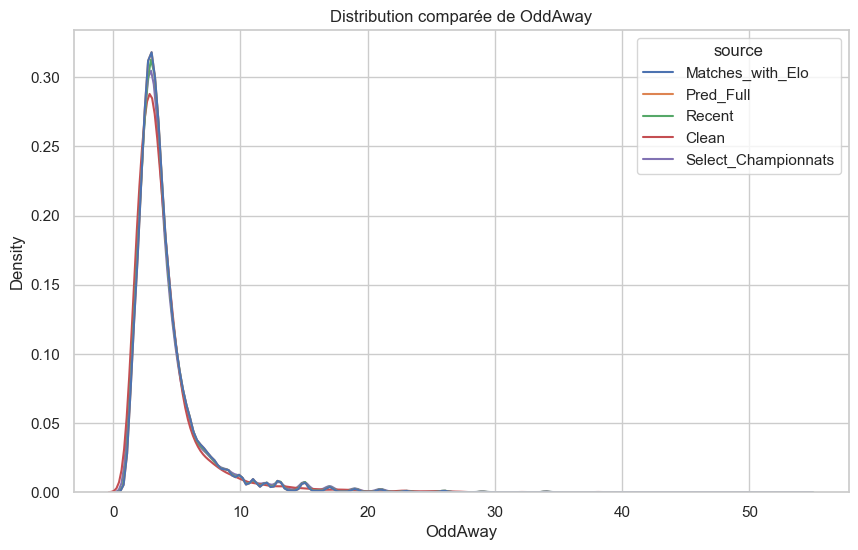

In [56]:
for col in ["OddHome", "OddDraw", "OddAway"]:
    plt.figure(figsize=(10,6))
    sns.kdeplot(data=df_compare, x=col, hue="source", common_norm=False)
    plt.title(f"Distribution comparée de {col}")
    plt.show()

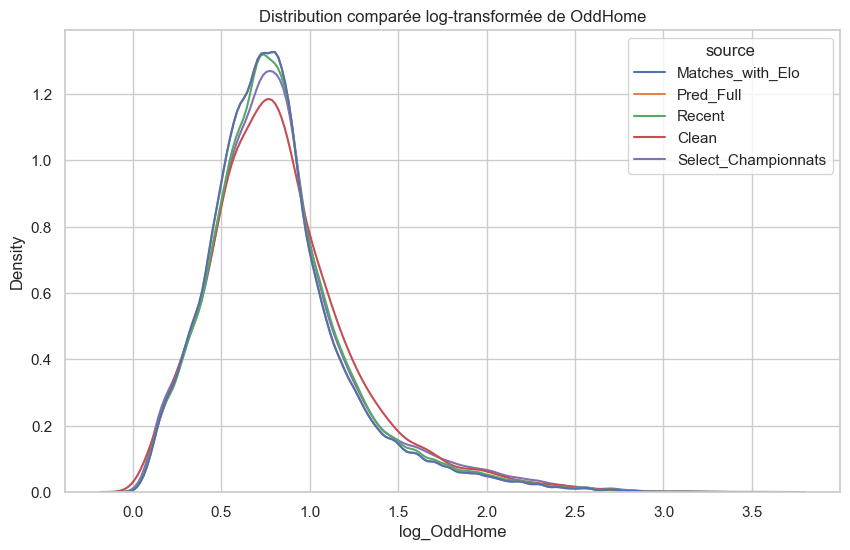

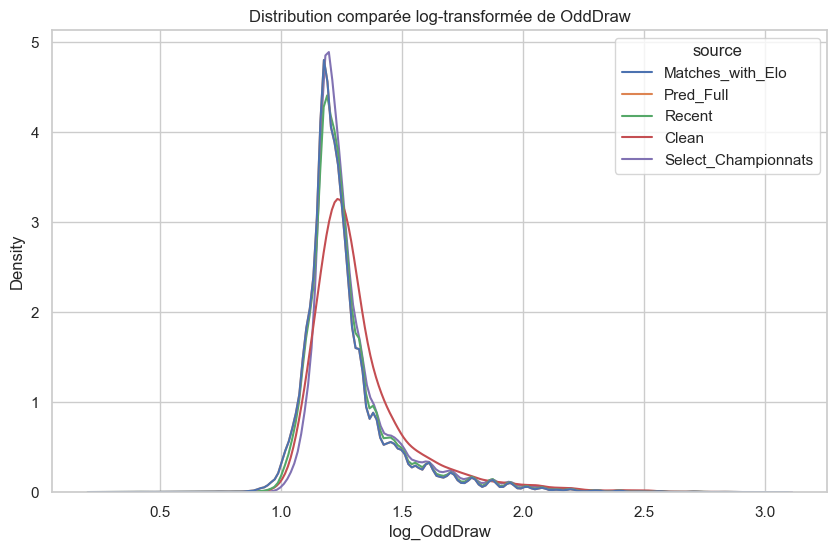

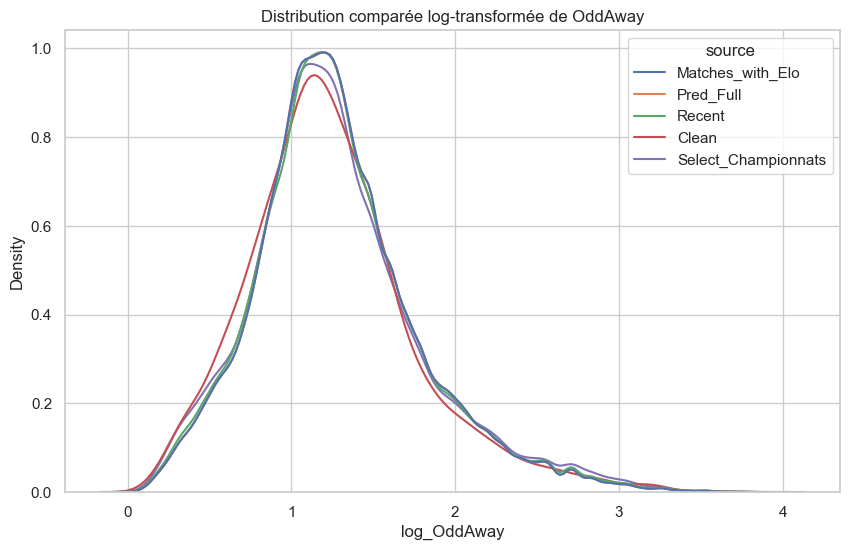

In [57]:
for col in ["OddHome", "OddDraw", "OddAway"]:
    df_valid = df_compare[df_compare[col] > 0].copy()
    df_valid[f"log_{col}"] = np.log(df_valid[col])

    plt.figure(figsize=(10,6))
    sns.kdeplot(data=df_valid, x=f"log_{col}", hue="source", common_norm=False)
    plt.title(f"Distribution comparée log-transformée de {col}")
    plt.show()

### Variables dérivées

In [58]:
derived = ["EloDifference", "Form3Difference", "Form5Difference"]

for col in derived:
    if col in df_compare.columns:
        plt.figure(figsize=(10,6))
        sns.kdeplot(data=df_compare, x=col, hue="source", common_norm=False)
        plt.title(f"Distribution comparée de {col}")
        plt.show()

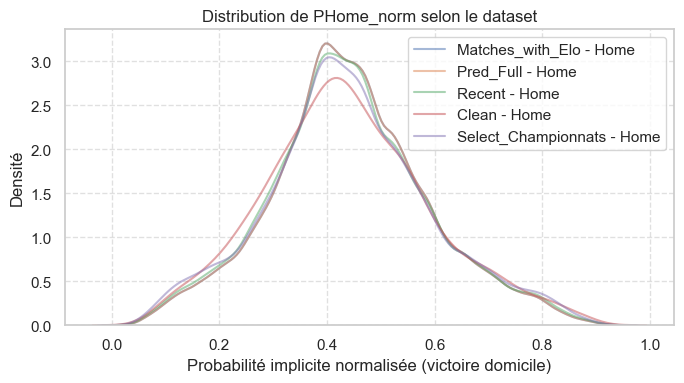

In [59]:
plt.figure(figsize=(7,4))

for name, df in dfs.items():
    if not {"PHome_norm","PAway_norm","PDraw_norm"}.issubset(df.columns):
        continue
    sns.kdeplot(df["PHome_norm"], label=f"{name} - Home", fill=False, alpha=0.5)

plt.title("Distribution de PHome_norm selon le dataset")
plt.xlabel("Probabilité implicite normalisée (victoire domicile)")
plt.ylabel("Densité")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [60]:
key_cols = [
    "EloDiff", "EloTotal", "EloAdvantage",
    "Form3Diff", "Form5Diff",
    "PHome_norm", "PDraw_norm", "PAway_norm"
]

summary_na = []
for name, df in dfs.items():
    row = {"Dataset": name}
    for col in key_cols:
        if col in df.columns:
            row[col] = (1 - df[col].isna().mean()) * 100
        else:
            row[col] = np.nan
    summary_na.append(row)

summary_na_df = pd.DataFrame(summary_na).set_index("Dataset").round(1)
display(summary_na_df)

,EloDiff,EloTotal,EloAdvantage,Form3Diff,Form5Diff,PHome_norm,PDraw_norm,PAway_norm
Dataset,,,,,,,,
Matches_with_Elo,90.6,90.6,90.6,99.7,99.7,98.4,98.4,98.4
Pred_Full,90.6,90.6,90.6,99.7,99.7,98.4,98.4,98.4
Recent,91.0,91.0,91.0,99.6,99.6,99.8,99.8,99.8
Clean,91.5,91.5,91.5,100.0,100.0,100.0,100.0,100.0
Select_Championnats,90.1,90.1,90.1,100.0,100.0,100.0,100.0,100.0


C:\Users\Alban\AppData\Local\Temp\ipykernel_24244\3668514980.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_df["Dataset"], y=summary_df["Complétude (%)"], palette="Blues_r")


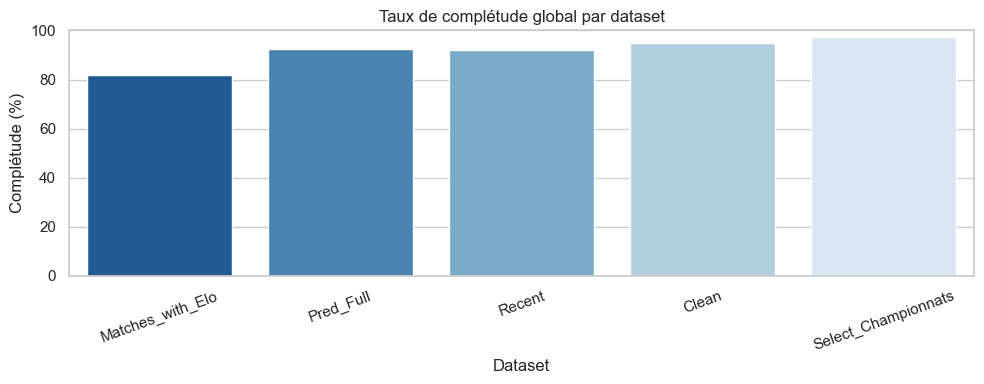

C:\Users\Alban\AppData\Local\Temp\ipykernel_24244\3668514980.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_df["Dataset"], y=summary_df["Lignes"], palette="Purples_r")


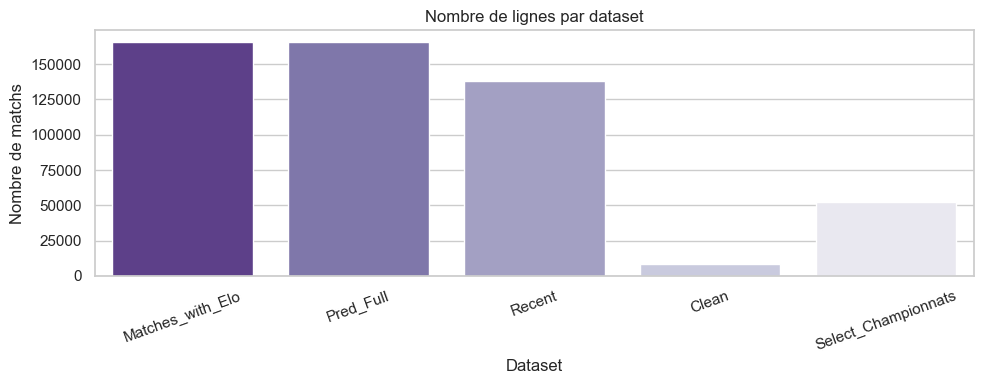

In [61]:
plt.figure(figsize=(10,4))
sns.barplot(x=summary_df["Dataset"], y=summary_df["Complétude (%)"], palette="Blues_r")
plt.title("Taux de complétude global par dataset")
plt.ylabel("Complétude (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(x=summary_df["Dataset"], y=summary_df["Lignes"], palette="Purples_r")
plt.title("Nombre de lignes par dataset")
plt.ylabel("Nombre de matchs")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [62]:
print("Synthèse comparativen")
for _, row in summary_df.iterrows():
    print(f"{row['Dataset']:25s} | {int(row['Lignes']):8,d} lignes | "
          f"{row['Colonnes']:3d} colonnes | "
          f"{row['Année min']}–{row['Année max']} | "
          f"Complétude : {row['Complétude (%)']:.1f}%")


Synthèse comparativen
Matches_with_Elo          |  165,619 lignes |  67 colonnes | 2000.0–2025.0 | Complétude : 82.0%
Pred_Full                 |  165,619 lignes |  48 colonnes | 2000.0–2025.0 | Complétude : 92.2%
Recent                    |  138,312 lignes |  46 colonnes | 2006.0–2025.0 | Complétude : 92.0%
Clean                     |    8,478 lignes |  35 colonnes | 2024.0–2025.0 | Complétude : 94.9%
Select_Championnats       |   52,580 lignes |  48 colonnes | 2006.0–2025.0 | Complétude : 97.3%
